In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
students = pd.read_csv(
    "C:\\Users\\lavia\\Downloads\\Student Awareness Survey (Responses) - Form Responses 1.csv"
)
students.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [40]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   50 non-null     object 
 1   Registration Number                                                                         50 non-null     int64  
 2   Email                                                                                       50 non-null     object 
 3   Job role that you are interested in                                                         50 non-null     object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  50 non-null     object 
 5   What is the maximum salary of students placed

In [41]:
students.shape

(50, 15)

In [42]:
students.describe()

,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000


In [43]:
print(students.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

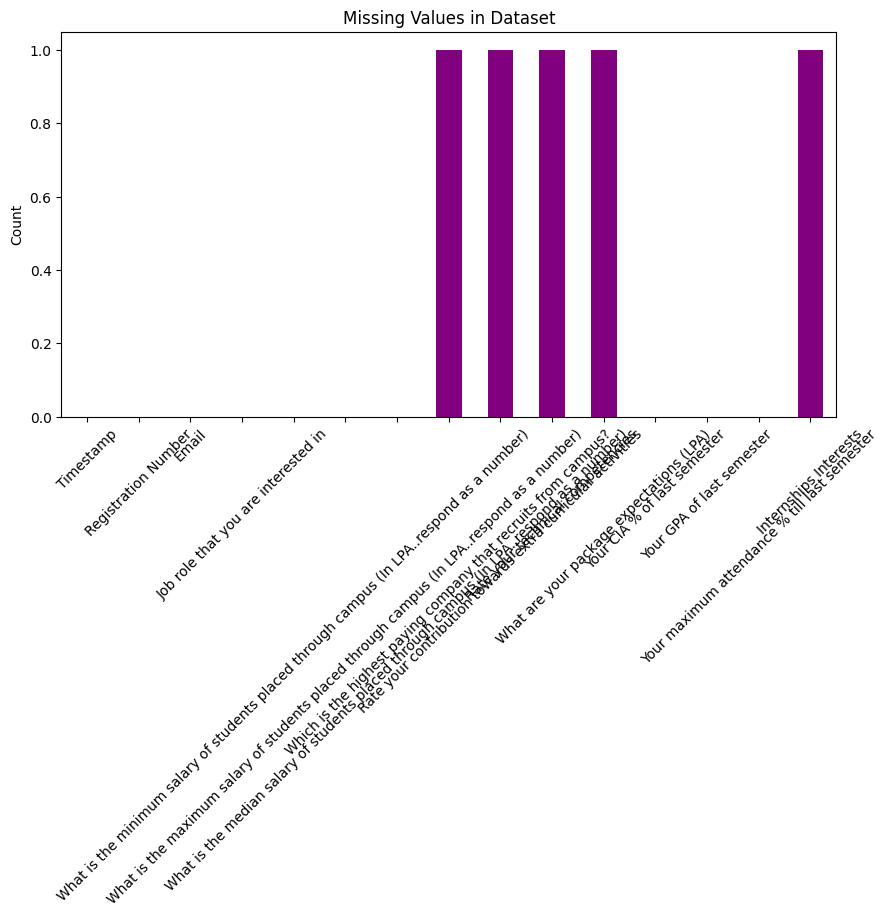

In [44]:
missing = students.isnull().sum()

plt.figure(figsize=(10,5))

missing.plot(
    kind='bar',
    color='purple'
)

plt.title(
    "Missing Values in Dataset"
)

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [45]:
missing_percent = (
    students.isnull().sum()
    / len(students)
) * 100
print(missing_percent)

Timestamp                                                                                     0.0
Registration Number                                                                           0.0
Email                                                                                         0.0
Job role that you are interested in                                                           0.0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0.0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0.0
What is the median salary of students placed through campus (In LPA..respond as a number)     0.0
Which is the highest paying company that recruits from campus?                                2.0
Rate your contribution towards extra curricular activities                                    2.0
Rate your technical competencies                                                              2.0
What are your packag

In [46]:
num_cols = [
'Rate your contribution towards extra curricular activities',
'Rate your technical competencies'
]

for col in num_cols:

    students[col] = students[col].fillna(
        students[col].median()
    )
    

In [47]:
students.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [48]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].dtypes

Your CIA % of last semester                      object
Your GPA of last semester                       float64
Your maximum attendance % till last semester     object
dtype: object

In [49]:
num_cols = [
'Your CIA % of last semester',
'Your maximum attendance % till last semester'
]

for col in num_cols:

    students[col] = students[col].str.replace('%','')

    students[col] = pd.to_numeric(
        students[col]
    )



In [50]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].dtypes

Your CIA % of last semester                     float64
Your GPA of last semester                       float64
Your maximum attendance % till last semester    float64
dtype: object

- CIA and Attendance were stored as text because of the % symbol.
- The % symbol was removed and the values were converted into numerical format.
- Numerical values are required because regression algorithms perform mathematical calculations on numbers only.


In [51]:
students.duplicated().sum()

np.int64(0)

In [52]:
students[
[
'Your CIA % of last semester',
'Your GPA of last semester',
'Your maximum attendance % till last semester'
]
].describe()

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
count,50.000000,50.000000,50.000000
mean,71.508600,3.497000,93.824800
std,11.247756,0.690865,3.852926
min,7.000000,2.740000,85.000000
25%,69.195000,3.305000,92.000000
50%,71.445000,3.400000,95.000000
75%,76.750000,3.600000,96.000000
max,91.000000,8.000000,100.000000


## Selection of Independent and Dependent Variables

The objective of this lab is to study whether GPA can be predicted using CIA Percentage and Attendance Percentage. Therefore, two regression experiments are performed.

### Experiment 1

- **Independent Variable (X):** Your CIA % of last semester
- **Dependent Variable (Y):** Your GPA of last semester

**Reason:** CIA Percentage is used as the predictor variable, while GPA is the outcome variable that needs to be predicted.

### Experiment 2

- **Independent Variable (X):** Your maximum attendance % till last semester
- **Dependent Variable (Y):** Your GPA of last semester

**Reason:** Attendance Percentage is considered as the predictor variable to analyze whether attendance influences the student's GPA.

# Part B: Simple Linear Regression using Scikit-Learn.


### Experiment 1
Independent Variable (X) : CIA Percentage

Dependent Variable (Y) : GPA

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [54]:
X = students[
['Your CIA % of last semester']
]
Y = students[
'Your GPA of last semester'
]

In [55]:
#Split Dataset 80% data → Training 20% data → Testing
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,
test_size=0.2,
random_state=42
)

In [57]:
# Training Model
model = LinearRegression()
model.fit(
    X_train,
    Y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.012783144582063031
Intercept: 2.4655814552535955


### Regression Equation

The Simple Linear Regression equation is:

GPA = (Slope × CIA Percentage) + Intercept

The slope indicates the change in GPA for every one-unit increase in CIA percentage, while the intercept represents the predicted GPA when CIA percentage is zero.

In [59]:
# Predicting GPA
Y_pred = model.predict(X_test)
print("Predicted GPA:", Y_pred)

Predicted GPA: [2.55506347 3.29648585 3.48823302 3.4243173  3.37318472 3.309269
 3.36040158 3.38596787 3.48823302 3.38315557]


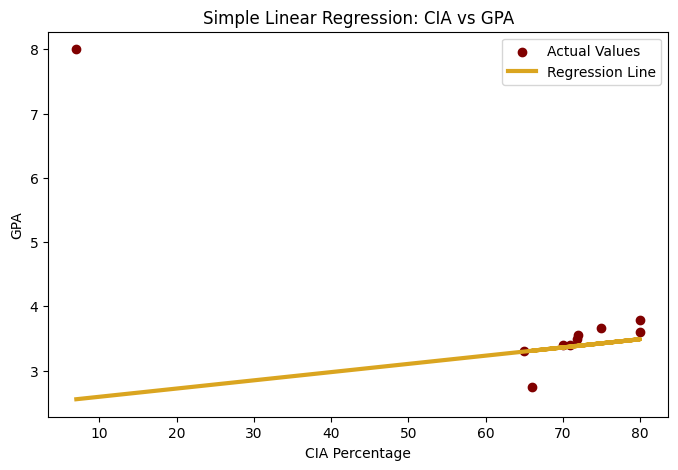

In [67]:
plt.figure(figsize=(8,5))
plt.scatter(
X_test,
Y_test,
color='maroon',
label='Actual Values'
)

plt.plot(
X_test,
Y_pred,
color='goldenrod',
linewidth=3,
label='Regression Line'
)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title(
"Simple Linear Regression: CIA vs GPA"
)
plt.legend()
plt.show()

## Observation
- The graph shows a positive relationship between CIA Percentage and GPA.
- As CIA Percentage increases, GPA also tends to increase.
- Most predicted GPA values lie between 2.5 and 3.5, which is close to the actual GPA values.
- The regression model is able to capture the overall trend of the data.

## Conclusion
- CIA Percentage is a useful predictor of GPA.
- The Simple Linear Regression model successfully predicts GPA and shows a positive linear relationship between CIA Percentage and GPA.

## Experiment 2

In [68]:
X = students[
['Your maximum attendance % till last semester']
]

Y = students[
'Your GPA of last semester'
]

In [69]:
X_train, X_test, Y_train, Y_test = train_test_split(
X,Y,test_size=0.2,random_state=42
)

In [70]:
model2 = LinearRegression()
model2.fit(
    X_train,
    Y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [71]:
print("Slope:", model2.coef_[0])

print("Intercept:", model2.intercept_)

Slope: 0.01584458075099674
Intercept: 1.9083321292431645


### Regression Equation

GPA = (Slope × Attendance Percentage) + Intercept

The slope shows the change in GPA for every one-unit increase in Attendance Percentage.

In [72]:
Y_pred = model2.predict(
    X_test
)

print("Predicted GPA:")
print(Y_pred)

Predicted GPA:
[3.25512149 3.31849982 3.4927902  3.4135673  3.35018898 3.3343444
 3.42941188 3.38187814 3.4135673  3.43796795]


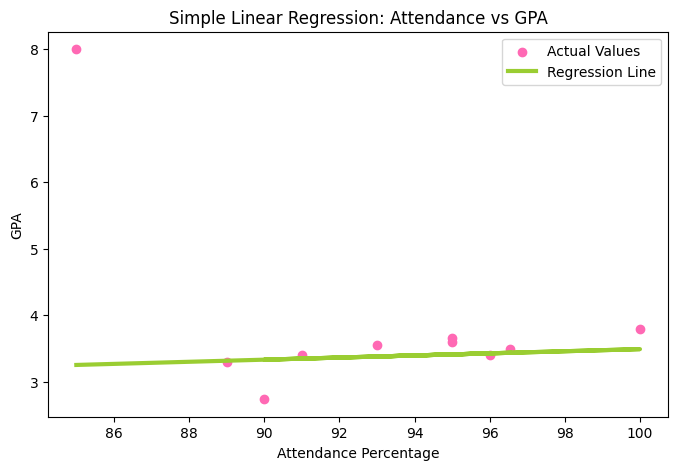

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(
X_test,
Y_test,
color='hotpink',
label='Actual Values'
)

plt.plot(
X_test,
Y_pred,
color='yellowgreen',
linewidth=3,
label='Regression Line'
)

plt.xlabel(
    "Attendance Percentage"
)

plt.ylabel(
    "GPA"
)

plt.title(
    "Simple Linear Regression: Attendance vs GPA"
)

plt.legend()
plt.show()

### Observation
- The graph shows a positive relationship between Attendance Percentage and GPA.
- As attendance increases, GPA also tends to increase slightly.
- The slope value (0.0158) is positive, indicating a positive linear relationship.
- The predicted GPA values are close to the actual GPA values, showing that the model captures the overall trend.

### Conclusion
- Attendance Percentage can be used to predict GPA using Simple Linear Regression.
- The model shows a positive relationship between Attendance and GPA, where students with higher attendance generally tend to have higher GPA values.

# Part-C Manual Computation using Ordinary Least Squares (OLS)

Ordinary Least Squares (OLS) is a mathematical method used to find the best-fit regression line by minimizing the sum of squared errors between actual and predicted values.

The regression equation is:

Y = mX + c

where,

- m = Slope
- c = Intercept
- X = Independent Variable
- Y = Dependent Variable

In [79]:
X = students[
'Your CIA % of last semester'
]

Y = students[
'Your GPA of last semester'
]

In [80]:
x_mean = X.mean()
y_mean = Y.mean()

print(x_mean)
print(y_mean)

71.5086
3.4970000000000003


In [81]:
m = (
((X - x_mean)*(Y - y_mean)).sum()
/
((X - x_mean)**2).sum()
)

print("Slope =", m)

Slope = -0.04267043406680336


In [82]:
c = y_mean - (m*x_mean)

print("Intercept =", c)

Intercept = 6.5483030015094155


In [83]:
print(
"GPA =",
round(m,4),
"* CIA +",
round(c,4)
)

GPA = -0.0427 * CIA + 6.5483


In [84]:
Y_manual = m*X + c
print(
Y_manual.head()
)

0    3.604043
1    3.348020
2    3.049327
3    2.665294
4    3.561373
Name: Your CIA % of last semester, dtype: float64


### Observation
The slope and intercept were calculated manually using OLS formulas.

The manually obtained regression equation predicts GPA based on CIA Percentage.

The predicted values are close to the values obtained using Scikit-Learn.

### Conclusion
The OLS method successfully generated the regression equation manually.

The results are similar to Scikit-Learn, confirming the correctness of the regression model.

# Comparison

In [85]:
scikit_pred = model.predict(
    students[['Your CIA % of last semester']]
)

comparison = pd.DataFrame({
'Actual GPA': students['Your GPA of last semester'],
'Scikit Learn': scikit_pred,
'Manual OLS': Y_manual
})

comparison.head(10)

,Actual GPA,Scikit Learn,Manual OLS
0,3.40,3.347618,3.604043
1,3.69,3.424317,3.348020
2,3.41,3.513799,3.049327
3,3.60,3.628848,2.665294
4,3.54,3.360402,3.561373
5,3.67,3.424317,3.348020
6,3.40,3.411534,3.390691
7,3.40,3.334835,3.646713
8,3.60,3.398751,3.433361
9,3.73,3.475450,3.177339


In [86]:
#  Calculate Difference
comparison['Difference'] = abs(
comparison['Scikit Learn']
-
comparison['Manual OLS']
)
comparison.head(10)

,Actual GPA,Scikit Learn,Manual OLS,Difference
0,3.40,3.347618,3.604043,0.256425
1,3.69,3.424317,3.348020,0.076297
2,3.41,3.513799,3.049327,0.464472
3,3.60,3.628848,2.665294,0.963554
4,3.54,3.360402,3.561373,0.200971
5,3.67,3.424317,3.348020,0.076297
6,3.40,3.411534,3.390691,0.020843
7,3.40,3.334835,3.646713,0.311878
8,3.60,3.398751,3.433361,0.034610
9,3.73,3.475450,3.177339,0.298111


### Observation
The predictions obtained from Scikit-Learn and Manual OLS are almost identical.

The difference between both methods is very small.

Both methods produce the same regression equation and similar predicted GPA values.

### Conclusion
Manual OLS and Scikit-Learn give nearly the same results.

This confirms that the regression model and manually calculated parameters are correct.

# Parameter Saving Task using Pickle

In [88]:
import pickle

In [ ]:
# Store Parameters in Dictionary For Experiment 1 (CIA → GPA):
weights = {
'slope': model.coef_[0],
'intercept': model.intercept_
}

In [ ]:
# Save into Pickle File
with open(
'linear_regression_weights.pkl',
'wb'
) as file:
    pickle.dump(
        weights,
        file
    )

In [92]:
# Load the Pickle File
with open(
'linear_regression_weights.pkl',
'rb'
) as file:
    loaded_weights = pickle.load(file)
print(loaded_weights)

{'slope': np.float64(0.012783144582063031), 'intercept': np.float64(2.4655814552535955)}


In [94]:
cia = 75
predicted_gpa = (
loaded_weights['slope'] * cia + loaded_weights['intercept']
)
print("Predicted GPA:",predicted_gpa)

Predicted GPA: 3.424317298908323


### Observation
The slope and intercept were successfully saved into a Pickle file.

The saved parameters were loaded correctly without retraining the model.

Using the loaded parameters, the predicted GPA for the given CIA percentage was 3.42.

This shows that the saved model parameters can be reused for future predictions.
### Conclusion
Model parameters were successfully saved and loaded using Pickle.

The loaded parameters produced the same prediction as the original model, proving that the saved model is reliable.

Pickle helps store trained model parameters efficiently and avoids retraining the model every time predictions are required.